# 11. Мини-проект. Практика

## Постановка задачи

Подобрать оптимальный алгоритм для оценки аплифт-эффекта от рекламных предложений. Наш клиент — французское рекламное агентство criteo. Оно предоставило нам данные о показах рекламы и отклике пользователей на рекламные предложения. Нужно подобрать модель для показа рекламных предложений пользователям. Описание датасета здесь.

## Критерии оценивания

- 2 балла	Построен валидационный датасет. 
- 2 балла	Построен S-learner. Оценено качество с помощью qini curve.
- 2 балла	Построен T-learner. Оценено качество с помощью qini curve.
- 2 балла	Построен X-learner. Оценено качество с помощью qini curve.
- 2 балла	Построен R-learner. Оценено качество с помощью qini curve.
- 2 балла	Построен UpliftRandomForest. Оценено качество с помощью qini curve.
- 3 балла	Сделан вывод о том, какие модели лучше использовать в этом бизнес-кейсе.

## Подсказки

- Всегда нужен валидационный сет, как его построить? 
- Давайте ударим всем арсеналом по задаче! Как измерить качество полученных значений аплифта?
- Какой подход оказался лучше всего? Почему?


## Погрузим библиотеки

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, CatBoostRegressor
from causalml.inference.meta import BaseRClassifier, BaseSClassifier, BaseTClassifier, BaseXClassifier
from causalml.inference.tree import (
    UpliftRandomForestClassifier,
    UpliftTreeClassifier,
    uplift_tree_plot,
    uplift_tree_string,
)
from sklift.models import SoloModel, TwoModels
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

Failed to import duecredit due to No module named 'duecredit'


## 1. Погрузим данные

In [3]:
df = pd.read_csv("data_add5/criteo-uplift-v2.1.csv")
df.head(3)

,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.976429,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
1,12.616365,10.059654,9.002689,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0
2,12.616365,10.059654,8.964775,4.679882,10.280525,4.115453,0.294443,4.833815,3.955396,13.190056,5.300375,-0.168679,1,0,0,0


In [9]:
print(f"Пропусков в df: {int(df.isna().sum().sum())}")
print(f"Столбцов с пропусками: {missing_by_column.shape[0]}")
print()
df.info()

Пропусков в df: 0
Столбцов с пропусками: 0

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13979592 entries, 0 to 13979591
Data columns (total 16 columns):
 #   Column      Dtype  
---  ------      -----  
 0   f0          float64
 1   f1          float64
 2   f2          float64
 3   f3          float64
 4   f4          float64
 5   f5          float64
 6   f6          float64
 7   f7          float64
 8   f8          float64
 9   f9          float64
 10  f10         float64
 11  f11         float64
 12  treatment   int64  
 13  conversion  int64  
 14  visit       int64  
 15  exposure    int64  
dtypes: float64(12), int64(4)
memory usage: 1.7 GB


## 2. Построим валидационный датасет. 

In [ ]:
# Построение валидационного датасета:
# train/test split со стратификацией по treatment и target
target_col = 'conversion'
treatment_col = 'treatment'

# приведем его к бинарному формату
if df[treatment_col].dtype == 'object':
    df = df.copy()
    df[treatment_col] = df[treatment_col].apply(lambda x: 0 if x == 'No Offer' else 1)

# Если conversion отсутствует, восстановим его из target_class
if target_col not in df.columns and 'target_class' in df.columns:
    df = df.copy()
    df[target_col] = df['target_class'].map({0: 0, 1: 1, 2: 0, 3: 1})

df_train, df_test = train_test_split(
    df,
    stratify=df[[treatment_col, target_col]],
    random_state=13,
    test_size=0.3
)

print('df shape:', df.shape)
print('df_train shape:', df_train.shape)
print('df_test shape:', df_test.shape)

display(df_train.head(3))

df shape: (13979592, 16)
df_train shape: (9785714, 16)
df_test shape: (4193878, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
13162840,12.616365,10.059654,8.915734,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,13.190056,5.300375,-0.168679,0,0,0,0
11010165,12.616365,10.059654,8.837421,4.679882,10.280525,4.115453,0.294443,4.833815,3.880455,13.190056,5.300375,-0.168679,1,0,0,0
11795432,12.616365,10.059654,8.253335,4.679882,10.280525,4.115453,0.294443,4.833815,3.899112,21.416100,5.300375,-0.168679,1,0,0,0


##  3. Построим S-learner. Оценим качество с помощью qini curve.

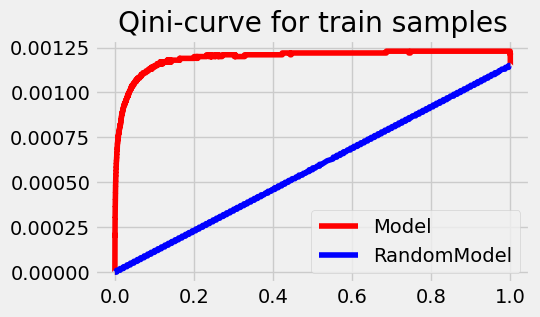

Qini score (train): 6049.861


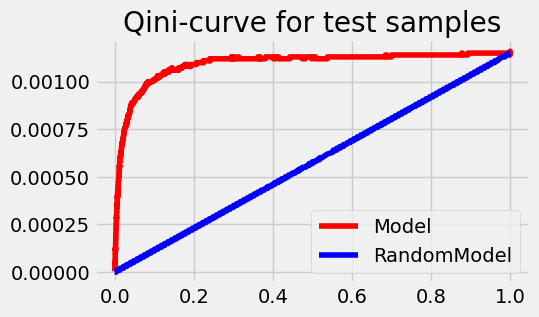

Qini score (test): 2171.093


In [12]:
# Возьмем функцию для оценки qini-curve 
def qini_df(df_eval, title='train', figsize=(5, 3)):
    ranked = df_eval.sort_values('uplift_score', ascending=False).copy()

    # Для датасета без target_class восстановим его из treatment/conversion
    if 'target_class' not in ranked.columns:
        ranked['target_class'] = np.select(
            [
                (ranked[treatment_col] == 0) & (ranked[target_col] == 0),
                (ranked[treatment_col] == 0) & (ranked[target_col] == 1),
                (ranked[treatment_col] == 1) & (ranked[target_col] == 0),
                (ranked[treatment_col] == 1) & (ranked[target_col] == 1),
            ],
            [0, 1, 2, 3],
            default=np.nan
        )

    N_c = sum(ranked['target_class'] <= 1)
    N_t = sum(ranked['target_class'] >= 2)

    ranked['n_c1'] = 0
    ranked['n_t1'] = 0
    ranked.loc[ranked.target_class == 1, 'n_c1'] = 1
    ranked.loc[ranked.target_class == 3, 'n_t1'] = 1
    ranked['n_c1/nc'] = ranked.n_c1.cumsum() / N_c
    ranked['n_t1/nt'] = ranked.n_t1.cumsum() / N_t

    ranked['uplift'] = round(ranked['n_t1/nt'] - ranked['n_c1/nc'], 5)
    ranked['random_uplift'] = round(
        ranked['uplift_score'].rank(pct=True, ascending=False) * ranked['uplift'].iloc[-1],
        5
    )
    ranked['n'] = ranked['uplift_score'].rank(pct=True, ascending=False)

    plt.figure(figsize=figsize)
    plt.plot(ranked['n'], ranked['uplift'], color='r', label='Model')
    plt.plot(ranked['n'], ranked['random_uplift'], color='b', label='RandomModel')
    plt.legend()
    plt.title(f'Qini-curve for {title} samples')
    plt.show()

    quni_score = (ranked['uplift'] - ranked['random_uplift']).sum()
    print(f'Qini score ({title}): {quni_score:.3f}')

# Факторы: используем признаки из исходного датасета Criteo (f0...f11)
feature_cols = [col for col in df_train.columns if col.startswith('f')]

# Создаем базовый S-learner
s_learner = SoloModel(
    estimator=CatBoostClassifier(random_seed=13, verbose=0)
 )

# Для обучения нам нужны датафрейм с факторами, таргет и колонка с фактом воздействия
s_learner = s_learner.fit(
    X=df_train[feature_cols],
    y=df_train[target_col],
    treatment=df_train[treatment_col]
 )

# Сделаем предсказание uplift-эффекта на обучающей выборке
uplift_vals = s_learner.predict(df_train[feature_cols])
df_train['uplift_score'] = uplift_vals

# Сделаем предсказание uplift-эффекта на тестовой выборке
uplift_vals = s_learner.predict(df_test[feature_cols])
df_test['uplift_score'] = uplift_vals

# Оценим качество uplift-моделирования
qini_df(df_train, title='train')
qini_df(df_test, title='test')

## Задание 4: Построим T-learner. Оценим качество с помощью qini curve.

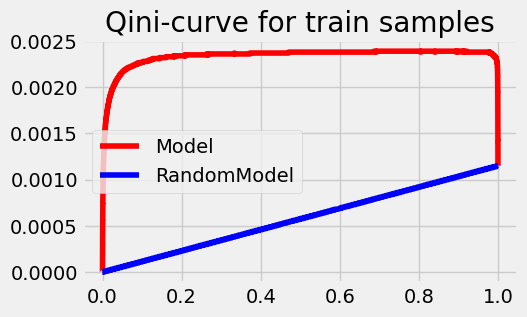

Qini score (train): 17230.761


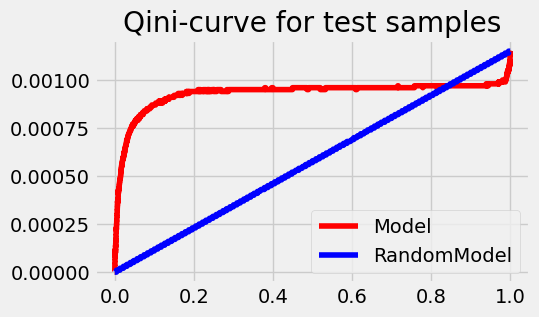

Qini score (test): 1489.514


In [13]:
# Создадим базовый T-learner
t_learner = TwoModels(
    estimator_trmnt=CatBoostClassifier(random_seed=13, verbose=0),
    estimator_ctrl=CatBoostClassifier(random_seed=13, verbose=0)
 )

# Для обучения нам нужны датафрейм с факторами, таргет и колонка с фактом воздействия
t_learner = t_learner.fit(
    X=df_train[feature_cols],
    y=df_train[target_col],
    treatment=df_train[treatment_col]
 )

# Сделаем предсказание uplift-эффекта на обучающей выборке
uplift_vals = t_learner.predict(df_train[feature_cols])
df_train['uplift_score'] = uplift_vals

# Сделаем предсказание uplift-эффекта на тестовой выборке
uplift_vals = t_learner.predict(df_test[feature_cols])
df_test['uplift_score'] = uplift_vals

# Оценим качество uplift-моделирования
qini_df(df_train, title='train')
qini_df(df_test, title='test')

## Задание 5: Построим X-learner. Оценим качество с помощью qini curve.

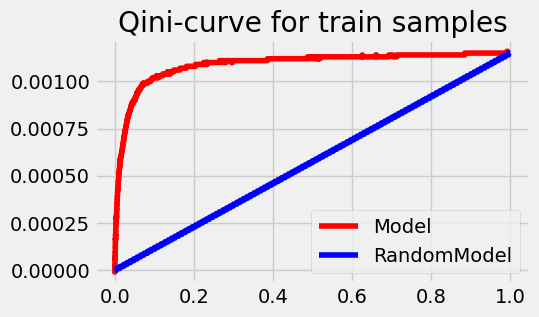

Qini score (train): 5037.290


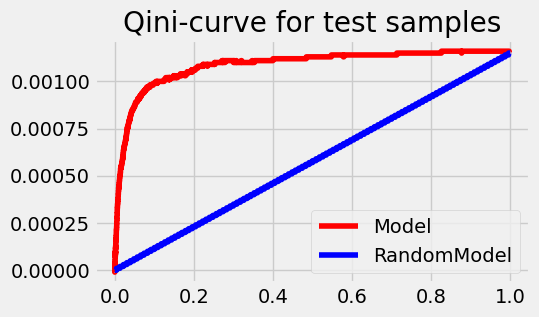

Qini score (test): 2143.977


In [14]:
# Давайте по данным построим X-learner

# Создадим базовый X-learner
x_learner = BaseXClassifier(
    outcome_learner=CatBoostClassifier(depth=5, random_seed=13, verbose=0),
    effect_learner=LinearRegression()
 )

# Для обучения нам нужны датафрейм с факторами, колонка с фактом воздействия
x_learner.fit(
    X=df_train[feature_cols],
    treatment=df_train[treatment_col],
    y=df_train[target_col]
 )

# Сделаем предсказание uplift-эффекта на обучающей выборке
uplift_vals = x_learner.predict(np.array(df_train[feature_cols].values.copy()))
df_train['uplift_score'] = uplift_vals

# Сделаем предсказание uplift-эффекта на тестовой выборке
uplift_vals = x_learner.predict(np.array(df_test[feature_cols].values.copy()))
df_test['uplift_score'] = uplift_vals

# Оценим качество uplift-моделирования
qini_df(df_train, title='train')
qini_df(df_test, title='test')

## Задание 6: Построим R-learner. Оценим качество с помощью qini curve.

In [ ]:
# Давайте по данным построим R-learner

# Создадим базовый R-learner
r_learner = BaseRClassifier(
    outcome_learner=CatBoostClassifier(depth=5, random_seed=13, verbose=0),
    effect_learner=LinearRegression(),
    random_state=42
 )

# Для обучения нам нужны датафрейм с факторами, колонка с фактом воздействия
r_learner.fit(
    X=df_train[feature_cols],
    treatment=df_train[treatment_col],
    y=df_train[target_col]
 )

# Сделаем предсказание uplift-эффекта на обучающей выборке
uplift_vals = r_learner.predict(np.array(df_train[feature_cols].values.copy()))
df_train['uplift_score'] = uplift_vals

# Сделаем предсказание uplift-эффекта на тестовой выборке
uplift_vals = r_learner.predict(np.array(df_test[feature_cols].values.copy()))
df_test['uplift_score'] = uplift_vals

# Оценим качество uplift-моделирования
qini_df(df_train, title='train')
qini_df(df_test, title='test')

## Задание 7: Построим UpliftRandomForest.. Оценим качество с помощью qini curve.

## Задание 8: Сравнение результатов и вывод по проделанной работе. Лучшая модель в этом бизнес-кейсе.